# Group 3 - Assignment Code

Performing SHAP analysis for GradBoost (Reading)...


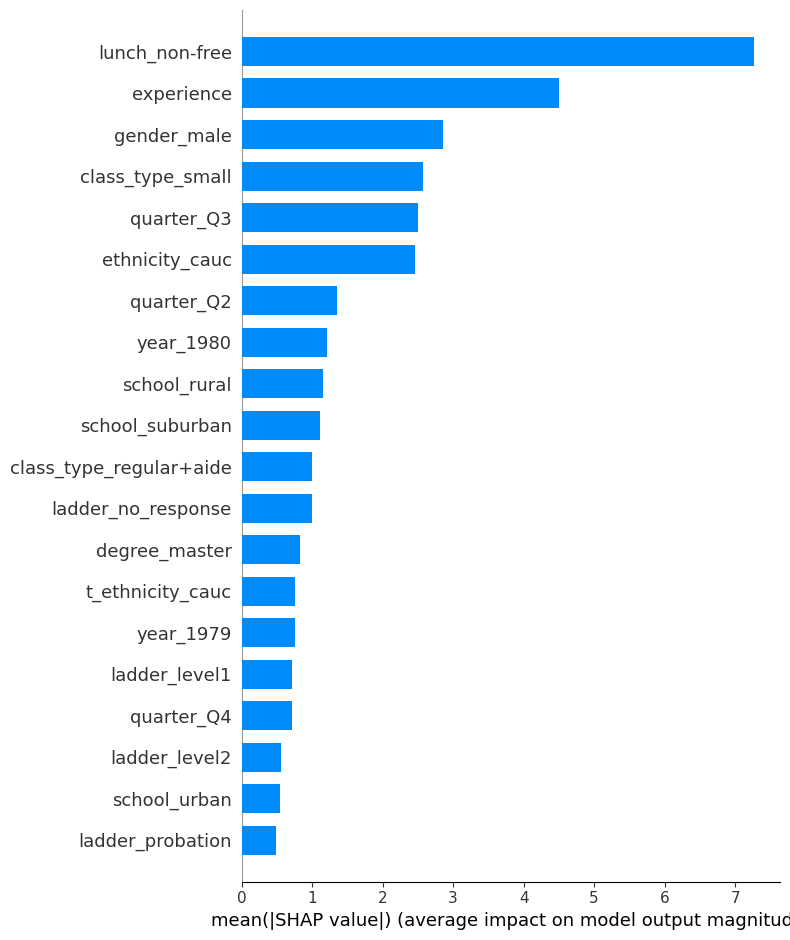

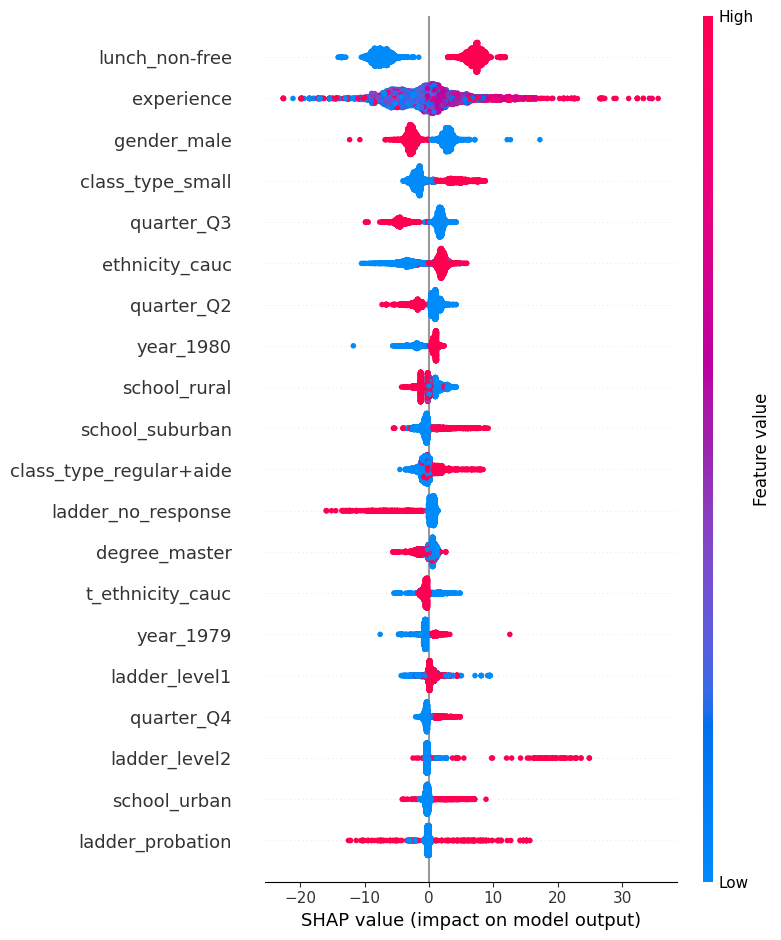

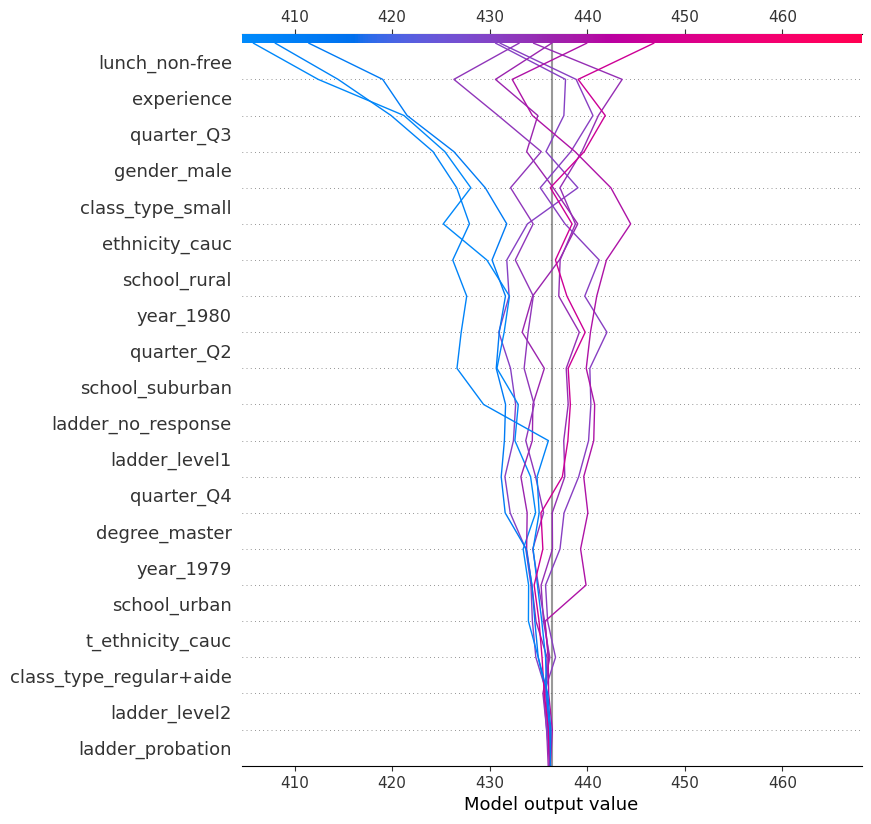

Performing SHAP analysis for GradBoost (Math)...


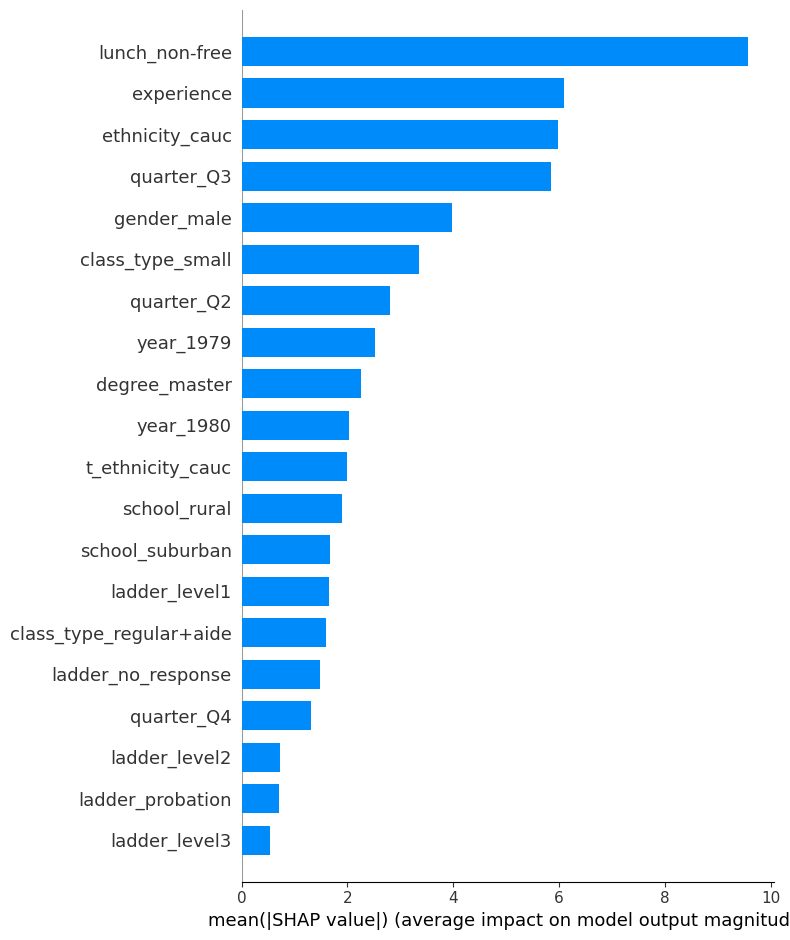

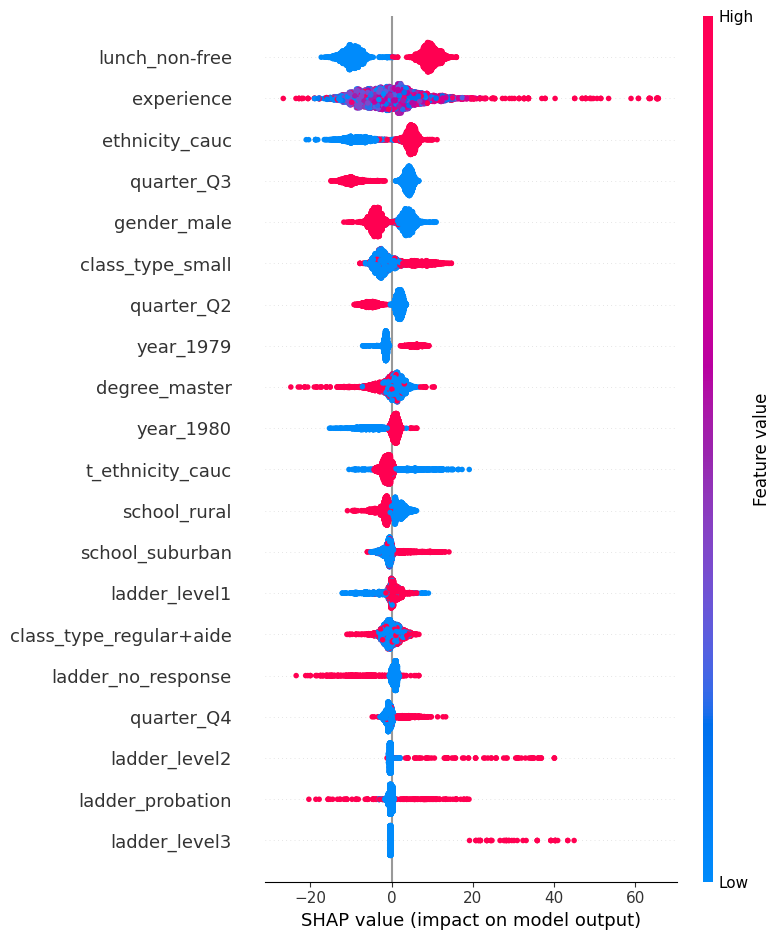

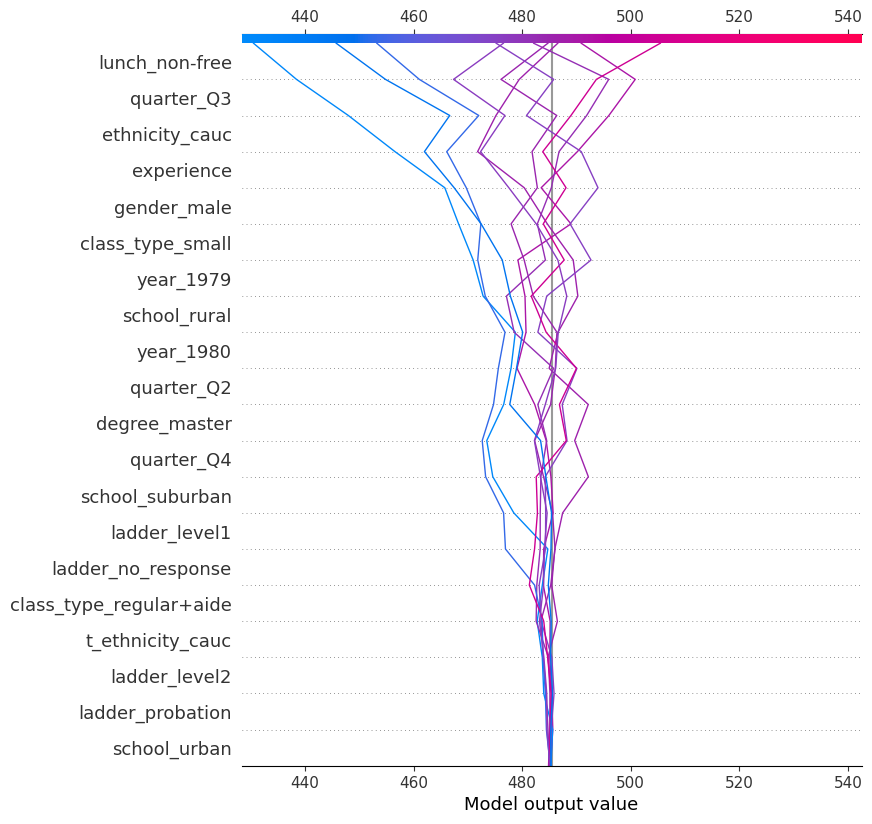

In [34]:
# Add SHAP analysis section
import shap

# Define SHAP analysis function
def analyze_with_shap(model_name, target, predictors, params, scale_cols):
    # Prepare data
    X = df[predictors].copy()
    
    # Feature standardization (consistent with original model processing)
    pre = ColumnTransformer([("scale", StandardScaler(), scale_cols)],
                           remainder="passthrough")
    X_scaled = pre.fit_transform(X)
    
    # Fit model with optimal parameters
    best_model = GradientBoostingRegressor(
        random_state=1,** params[model_name]
    )
    best_model.fit(X_scaled, target)
    
    # Initialize SHAP explainer
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_scaled)
    
    # Plot SHAP summary plot
    shap.summary_plot(shap_values, X_scaled, feature_names=predictors, plot_type="bar")
    
    # Plot swarm plot to show feature impact distribution
    shap.summary_plot(shap_values, X_scaled, feature_names=predictors)
    
    # Plot decision explanation for top 10 samples
    shap.decision_plot(explainer.expected_value, shap_values[:10], feature_names=predictors)

# Perform SHAP analysis for the reading score model
print("Performing SHAP analysis for GradBoost (Reading)...")
analyze_with_shap("GradBoost", target_read, predictors_rf, params_read, scale_cols)

# Perform SHAP analysis for the math score model
print("Performing SHAP analysis for GradBoost (Math)...")
analyze_with_shap("GradBoost", target_math, predictors_rf, params_math, scale_cols)